In [ ]:
import matplotlib.pyplot as plt # This is the API to matplotlib
import numpy as np # This is the API to numpy   

In [ ]:
def load_coffee_data():
    data = []
    for line in open('coffee.csv'):
        clean_line = line.strip() # Gets rid of \n from each line
        if len(clean_line) > 0: # Checks if the line is not empty
            clean_list = clean_line[1:-1].split('","') # gets rid of the "" before splitting each line
            data.append(clean_list)
    return data

data = load_coffee_data()

In [ ]:
import pandas as pd
coffee = pd.read_csv('coffee.csv')
coffee.head()

In [ ]:
coffee.iloc[[1,10],3]
coffee.loc[coffee.Year > 2010]

In [ ]:
# Finding a unique list of countries where the coffe beans are from
def countries(data):
    countries = []
    for i in range(1, len(data)): # Start from 1 to skip the header row
        if data[i][0] not in countries:
            countries.append(data[i][0])
    return countries

countries = countries(data)

In [ ]:
def avg_total_coffee_score(country, data):
    total_score = 0
    count = 0
    for line in data:
        if str(line[0]).strip() == country:
            total_score += float(line[21]) # Total Coffee Score is in the 22nd column, which is index 21
            count += 1
            
    if count == 0: # To avoid division by zero
        return 0
    else:
        return total_score/count

avg_total_coffee_score(countries[1], data) # Average total coffee score for the second country in the list

In [ ]:
# Create a dictionary to store the average total coffee score for each country
avg_coffee_score = {}
for country in countries:
    avg_coffee_score[country] = 0

for country in countries:
    avg_coffee_score[country] = avg_total_coffee_score(country, data)
    
avg_coffee_score

In [ ]:
# Find the country with the highest average total coffee score
def find_best_country(avg_coffee_score):
    highest_avg_score = 0
    best_country = ""
    for country in avg_coffee_score:
        if avg_coffee_score[country] > highest_avg_score: # Check if the average score is higher than the current highest score
            best_country = country
            highest_avg_score = avg_coffee_score[country]
    return best_country, highest_avg_score

best_country, highest_avg_score = find_best_country(avg_coffee_score)
print(f"The country with the highest average total coffee score is {best_country} with a score of {highest_avg_score:.2f}.")

In [ ]:
#Find the top 10 countries with the highest average total coffee score
def find_top_countries(avg_coffee_score):
    sorted_countries = dict(sorted(avg_coffee_score.items(), key=lambda item: item[1], reverse=True)) # lambda function to sort the value of the dictionary in descending order
    return sorted_countries

top_countries = find_top_countries(avg_coffee_score)

In [ ]:
top10_countries = dict(list(top_countries.items())[:10])

top10_countries_names = list(top10_countries.keys()) # Create a list with the names of the top 10 countries
top10_countries_scores = list(top10_countries.values()) # Create a list with the average total coffee scores of the top 10 countries

#Used plt.bar because I was plotting from two lists and not a dataframe
plt.figure(figsize=(12, 8)) # Set the size of the figure to be wider
plt.barh(y=top10_countries_names, width=top10_countries_scores, color = "darkred") # Create a bar chart
plt.title('Top 10 Countries with the Highest Average Total Coffee Score')
plt.xlabel('Country')
plt.ylabel('Average Total Coffee Score')
plt.xticks(rotation=90) # Rotate the x-axis labels for better readability
plt.xlim(75, 100) # Limits the y-axis to only display y-values between 75 and 100

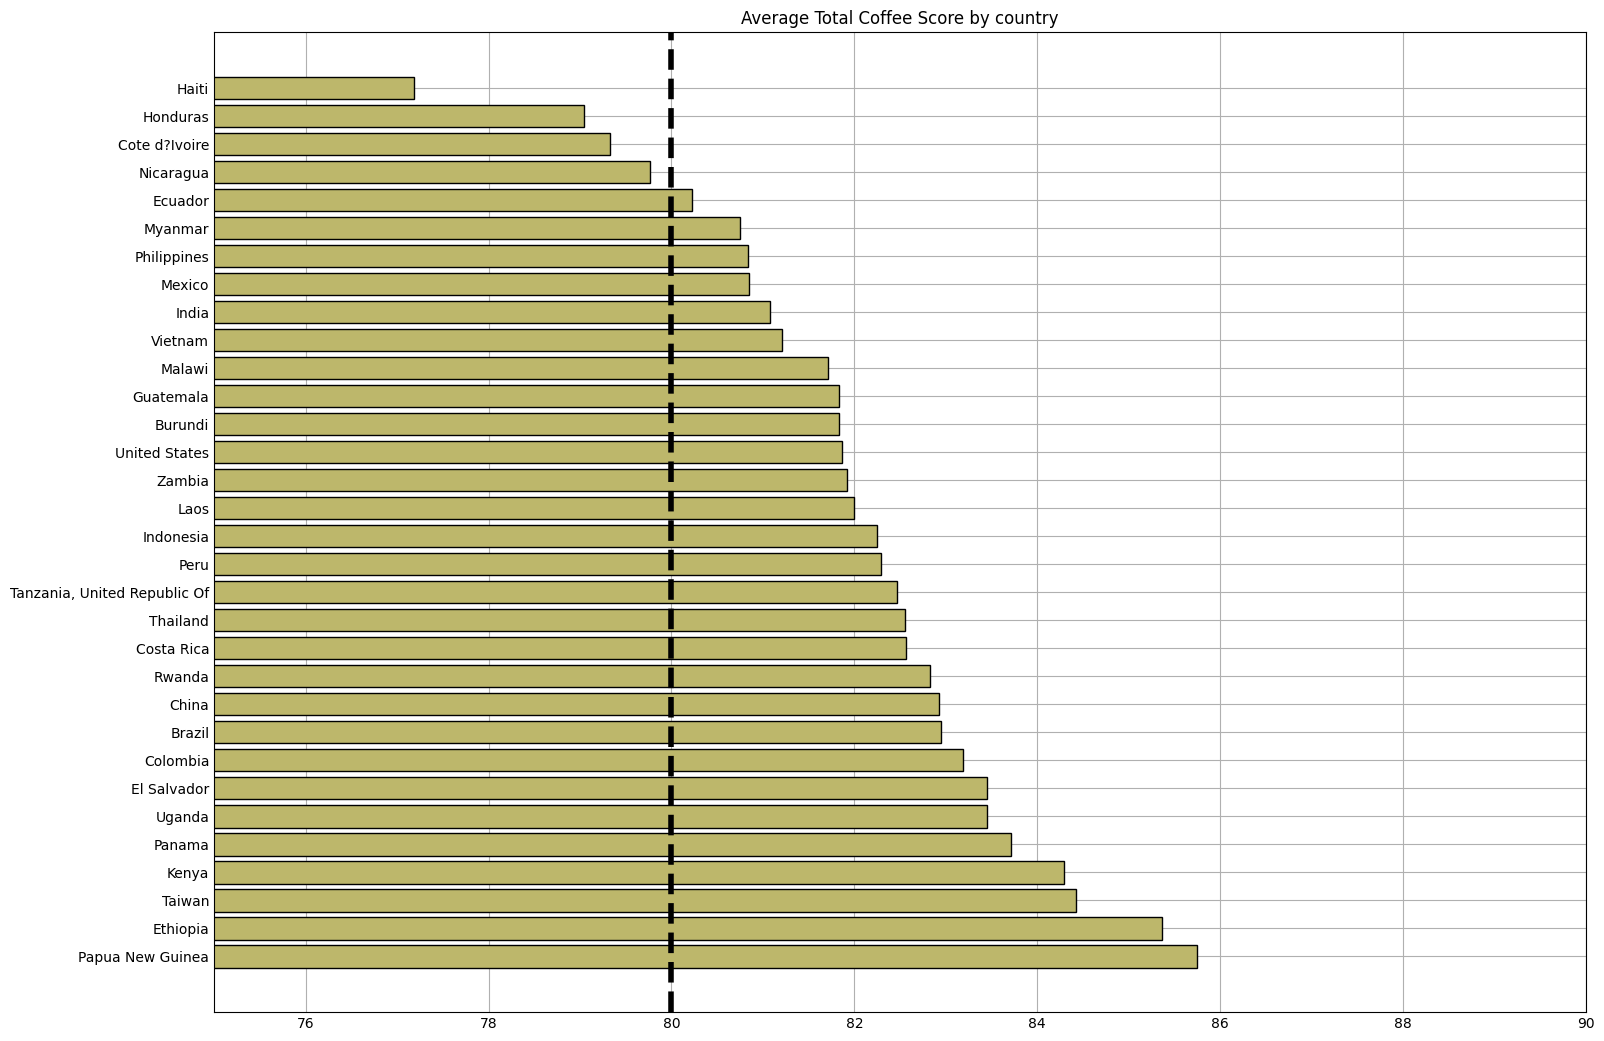

In [212]:
# I like the top 10 countries but want to show all of them for better representation
#NOTE: I can't use the dataframe plot functions because I had to calculate the average total coffee score for each country not each entry

plt.figure(figsize=(14, 10)) 
plt.barh(y=list(top_countries.keys()), width=list(top_countries.values()), color = "darkkhaki", edgecolor='black')
plt.title('Average Total Coffee Score by country')
plt.xlim(75,90) # Limits the y-axis to only display y-values between 75 and 100

plt.axvline(x=80, color='black', linestyle='--', linewidth=4) # Adds the speciality line at 80

(6.0, 10.0)

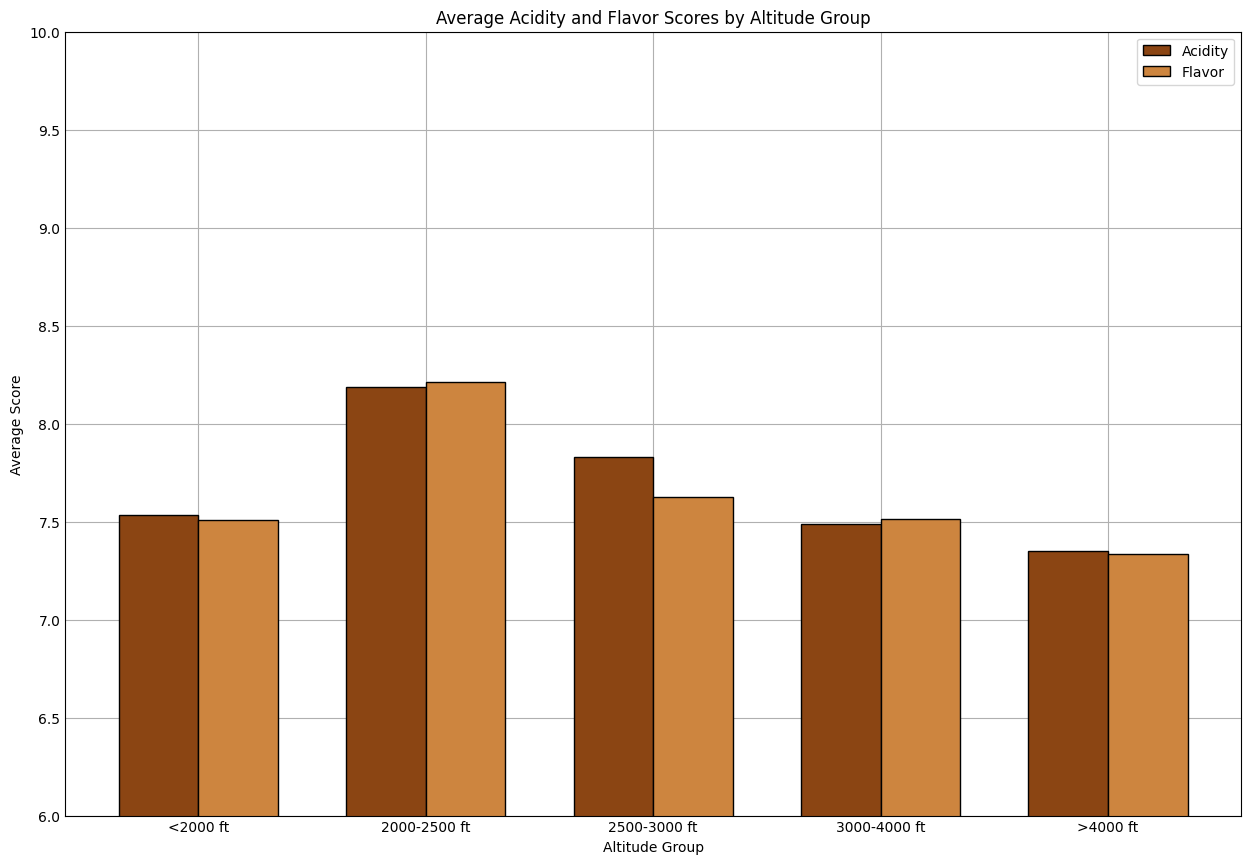

In [213]:
# Altitudes affect on acidity and flavor scores
#NOTE: I can't use the dataframe plot functions because I had to bucket the altitudes into groups

# Rename the columns to be more concise and easier to work with 
coffee = coffee.rename(columns={"Location.Altitude.Average": "Altitude",
                       "Data.Scores.Acidity": "Acidity",
                       "Data.Scores.Flavor": "Flavor"})

# Organize the altitudes into 6 groupings
very_low_alt = coffee.loc[coffee["Altitude"] < 2000] # less that 2000 feet
low_alt = coffee.loc[(coffee["Altitude"] >= 2000) & (coffee["Altitude"] < 2500)] # between 2000 and 2500 feet
medium_alt = coffee.loc[(coffee["Altitude"] >= 2500) & (coffee["Altitude"] < 3000)] # between 2500 and 3000 feet
high_alt = coffee.loc[(coffee["Altitude"] >= 3000) & (coffee["Altitude"] <= 4000)] # between 3000 and 4000 feet
very_high_alt = coffee.loc[coffee["Altitude"] > 4000] # 4000 feet or higher

# Find the average scores for any score type by altitude group
def avg_score_by_altitude_group(altitude_group, score):
    avg_score = altitude_group[score].mean()
    return avg_score

# Find average scores for acidity
avg_acidity_very_low_alt = avg_score_by_altitude_group(very_low_alt, "Acidity")
avg_acidity_low_alt = avg_score_by_altitude_group(low_alt, "Acidity")
avg_acidity_medium_alt = avg_score_by_altitude_group(medium_alt, "Acidity")
avg_acidity_high_alt = avg_score_by_altitude_group(high_alt, "Acidity")
avg_acidity_very_high_alt = avg_score_by_altitude_group(very_high_alt, "Acidity") 

# Find average scores for flavor
avg_flavor_very_low_alt = avg_score_by_altitude_group(very_low_alt, "Flavor")
avg_flavor_low_alt = avg_score_by_altitude_group(low_alt, "Flavor")
avg_flavor_medium_alt = avg_score_by_altitude_group(medium_alt, "Flavor")
avg_flavor_high_alt = avg_score_by_altitude_group(high_alt, "Flavor")
avg_flavor_very_high_alt = avg_score_by_altitude_group(very_high_alt, "Flavor")

#Plot a double bar graph to compare the average acidity and flavor scores for each altitude group
altitude_groups = ["<2000 ft", "2000-2500 ft", "2500-3000 ft", "3000-4000 ft", ">4000 ft"]
avg_acidity_scores = [avg_acidity_very_low_alt, avg_acidity_low_alt, avg_acidity_medium_alt, avg_acidity_high_alt, avg_acidity_very_high_alt]
avg_flavor_scores = [avg_flavor_very_low_alt, avg_flavor_low_alt, avg_flavor_medium_alt, avg_flavor_high_alt, avg_flavor_very_high_alt]
x = np.arange(len(altitude_groups))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(12, 8)) # Set the size of the figure to be wider
rects1 = ax.bar(x - width/2, avg_acidity_scores, width, label='Acidity', color = "saddlebrown", edgecolor='black') # Bar for acidity scores
rects2 = ax.bar(x + width/2, avg_flavor_scores, width, label='Flavor', color = "peru", edgecolor='black') # Bar for flavor scores
ax.set_xlabel('Altitude Group')
ax.set_ylabel('Average Score')
ax.set_title('Average Acidity and Flavor Scores by Altitude Group')

# Takes the label locations and sets the x-axis labels to be in the middle of the bars
ax.set_xticks(x)
ax.set_xticklabels(altitude_groups)

ax.legend() # To label the bars with acidity and flavor
ax.set_ylim(6,10) # With most beans being speciality grade small score differences matter a lot
